### 文本測試

In [8]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties  
winfont01 = FontProperties(fname=r"c:\windows\fonts\simsun.ttc", size=12) 
winfont02 = FontProperties(fname=r"c:\windows\fonts\kaiu.ttf", size=12) 

plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 設定字型為微軟正黑體
plt.rcParams['axes.unicode_minus'] = False                # 解決負號顯示問題

macfont = FontProperties(fname="/Library/Fonts/Arial Unicode.ttf", size=10) 

In [9]:
import sqlite3
import pandas as pd

DB_FILE = r"D:/NTPU_class/paper/code/mobile01_clawler/ntpu_paper.sqlite"

sql = """
WITH latest AS (
  SELECT
    article_id,
    MAX(created_at) AS max_created_at
  FROM eb_evaluation
  WHERE level = 1
    AND article_id IS NOT NULL
  GROUP BY article_id
)
SELECT
  a.id          AS article_id,
  a.link_id     AS link_id,
  a.url         AS url,
  a.title       AS title,
  a.post_time   AS post_time,
  a.content     AS content,
  a.word_count  AS word_count,
  a.reply_count AS reply_count,
  l.keyword     AS keyword,
  l.has_emotional_abuse AS y_rule,

  e.score_overall AS y_llm,
  e.confidence    AS llm_confidence,
  e.model_name,
  e.model_version,
  e.knowledge_base,
  e.created_at    AS eval_created_at
FROM articles a
JOIN links l
  ON a.link_id = l.id
LEFT JOIN latest t
  ON a.id = t.article_id
LEFT JOIN eb_evaluation e
  ON e.article_id = t.article_id
 AND e.created_at = t.max_created_at
 AND e.level = 1
WHERE a.content IS NOT NULL
  AND TRIM(a.content) <> '';
"""

with sqlite3.connect(DB_FILE) as conn:
    df = pd.read_sql_query(sql, conn)

df.head()


,article_id,link_id,url,title,post_time,content,word_count,reply_count,keyword,y_rule,y_llm,llm_confidence,model_name,model_version,knowledge_base,eval_created_at
0,68fce9b6af1137205015fd06,68f87edcaf1137700cb26e94,https://www.mobile01.com/topicdetail.php?f=330...,被爸媽情緒勒索很痛苦 心理諮商有效嗎?,2024-12-10 9:53,大家都遇過父母情緒勒索嗎？從小我就是一個很聽話的小孩，因為我爸媽控制慾很重，如果不聽他們的話...,397,8,情緒勒索,1,4.6,0.95,mistral,latest,pua_db,2025-11-24 12:02:47
1,68fce9f3af11377624f11eda,68f87edcaf1137700cb26e95,https://www.mobile01.com/topicdetail.php?f=292...,看完這篇其實 情緒勒索是不是也等於控制慾強?,2021-06-28 8:25,看完這篇其實 情緒勒索是不是也等於控制慾強?\n\n剛好在兩性版看到一段話 突然對控制慾強這...,2106,7,情緒勒索,1,4.0,0.90,mistral,latest,pua_db,2025-11-24 12:02:51
2,68fcea01af11377624f11edb,68f87edcaf1137700cb26e96,https://www.mobile01.com/topicdetail.php?f=37&...,沒有情緒勒索，只有忠言逆耳,2023-03-08 12:09,現在人(尤其是年輕人)遇到不好聽的話，就會說在情緒勒索他們\n實際上並不存在情緒勒索這種東西...,143,8,情緒勒索,1,3.0,0.80,mistral,latest,pua_db,2025-11-24 12:02:54
3,68fcea15af11377624f11edc,68f87edcaf1137700cb26e98,https://www.mobile01.com/topicdetail.php?f=594...,#書籍推薦 #不被情緒勒索的51個方法,2022-11-15 10:31,"(時間會證明,當初自己是對的...也會證明當初自己是錯的 ...?)\n(所以才需要每天寫日...",1248,0,情緒勒索,1,3.0,0.80,mistral,latest,pua_db,2025-11-24 12:02:57
4,68fcea6eaf11379f9c929394,68f87edcaf1137700cb26e9c,https://www.mobile01.com/topicdetail.php?f=292...,有關情緒勒索,2023-09-07 16:49,請問各位，我有個疑問\n如果只是問另一半要不要吃飯\n或著是問一起出去玩好不好，\n又或者問...,63,8,情緒勒索,1,1.0,1.00,mistral,latest,pua_db,2025-11-24 12:02:59


### 有的評分可能出錯 所以刪除沒有評分的部分

In [10]:
import pandas as pd
import numpy as np

# 先複製
dfm = df.copy()

# 基本清理
dfm["y_rule"] = dfm["y_rule"].astype(int)
dfm["y_llm"] = pd.to_numeric(dfm["y_llm"], errors="coerce")

# ✅ 刪除未評分（y_llm 為 NaN）
before = len(dfm)
dfm = dfm.dropna(subset=["y_llm"]).reset_index(drop=True)
after = len(dfm)

before, after

(1428, 1365)

### summary ( 樣本數、缺值)

In [11]:
summary = {
    "n_total": len(dfm),
    "y_rule_rate(%)": round(dfm["y_rule"].mean() * 100, 2),
    "y_llm_mean": round(dfm["y_llm"].mean(), 3),
    "y_llm_std": round(dfm["y_llm"].std(), 3),
    "word_count_mean": round(dfm["word_count"].mean(), 2) if "word_count" in dfm else None,
    "reply_count_mean": round(dfm["reply_count"].mean(), 2) if "reply_count" in dfm else None,
}
summary

{'n_total': 1365,
 'y_rule_rate(%)': np.float64(50.04),
 'y_llm_mean': np.float64(3.346),
 'y_llm_std': np.float64(0.998),
 'word_count_mean': np.float64(219.55),
 'reply_count_mean': np.float64(6.56)}

#### y_llm 分布（value_counts）

In [12]:
dfm["y_llm"].value_counts().head(15)

y_llm
4.0    534
3.0    266
3.6    141
2.0    116
4.2     95
3.5     63
0.0     47
1.0     44
3.8     16
3.2     10
3.7      7
4.6      6
3.4      6
5.0      6
4.3      2
Name: count, dtype: int64

#### 轉換 y_llm overall 分數變成 binary  

In [13]:
# Binary（先用 >=3，之後你要改切點很容易）
# TODO：這個我可能可以思考重新跑 讓他直接有一個binary
# TODO：之後可能測試一下不同的threshold
dfm["y_llm_bin"] = (dfm["y_llm"] >= 3.0).astype(int)

#### y_rule × y_llm_bin 交叉表

In [14]:
ct = pd.crosstab(dfm["y_rule"], dfm["y_llm_bin"], rownames=["y_rule"], colnames=["y_llm_bin"], margins=True)
ct


y_llm_bin,0,1,All
y_rule,,,
0,192,490,682
1,16,667,683
All,208,1157,1365


#### y_llm by y_rule 的描述統計

In [15]:
dfm.groupby("y_rule")["y_llm"].agg(["count", "mean", "std", "median", "min", "max"])

,count,mean,std,median,min,max
y_rule,,,,,,
0,682,2.925073,1.132422,3.0,0.0,5.0
1,683,3.766252,0.597802,4.0,0.0,5.0


#### Boxplot

<Figure size 640x480 with 0 Axes>

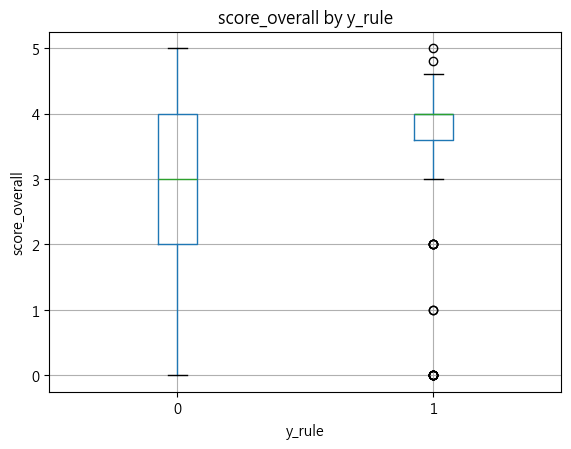

In [16]:
import matplotlib.pyplot as plt

plt.figure()
dfm.boxplot(column="y_llm", by="y_rule")
plt.title("score_overall by y_rule")
plt.suptitle("")
plt.xlabel("y_rule")
plt.ylabel("score_overall")
plt.show()

與未被規則標記之主文相比，被標記為情緒勒索之主文，其整體評分不僅顯著較高，且分布變異較小，顯示語義結構更為集中。

## 模型開始!~

- 斷詞方法 (tokenizer) -> 2
    - jieba
    - CKIP
- 表示法（Representation） -> 3
    - R1：TF-IDF
    - R2：Word2Vec(mean)
    - R3：fastText(mean)
- 模型（Model） -> 6
    - M1：Logistic Regression
    - M2：SVM（RBF kernel；不要 linear）
    - M3：SVM（Polynomial kernel；補充用）
    - M4：Random Forest
    - M5：XGBoost
    - M6：Neural Network（MLP）

| Representation | LR | SVM (RBF) | RF | XGBoost | MLP |
| -------------- | -: | --------: | -: | ------: | --: |
| TF-IDF         |  ✅ |         ✅ |  ✅ |       ✅ |   ❌ |
| w2v(mean)      |  ✅ |      (可選) |  ❌ |       ❌ |   ✅ |
| fastText(mean) |  ✅ |      (可選) |  ❌ |       ❌ |   ✅ |


Step 0｜匯入套件 + 全域參數

In [17]:
import os, re, io, time, contextlib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

# ===== optional: xgboost =====
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# ===== Parameters (you can tune) =====
RANDOM_SEED = 42
TEST_SIZE = 0.2

Y_RAW_COL = "y_llm"          # 原始評分欄位
TEXT_COL  = "content"        # 主文文字欄位（留言就改 comment_text）

THRESHOLD = 3                # y_llm_bin：>=3 -> 1
N_WORKERS = max(1, (os.cpu_count() or 4) - 1)

TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 5
TFIDF_NGRAM = (1, 2)

SVD_DIM = 300                # TF-IDF 給 SVM/RF/XGB 用
EMB_DIM = 200                # w2v / fastText mean 維度
W2V_EPOCHS = 10
FT_EPOCHS  = 10

STEP 1｜斷詞函式（jieba + CKIP）

In [23]:
import jieba

def normalize_text(text: str) -> str:
    if text is None:
        return ""
    return re.sub(r"\s+", " ", str(text)).strip()

def tokenize_jieba(text: str):
    text = normalize_text(text)
    if not text:
        return []
    return [t for t in jieba.cut(text, cut_all=False) if t.strip()]

_CKIP_WS = None
def get_ckip_ws():
    global _CKIP_WS
    if _CKIP_WS is None:
        from ckip_transformers.nlp import CkipWordSegmenter
        f_out, f_err = io.StringIO(), io.StringIO()
        with contextlib.redirect_stdout(f_out), contextlib.redirect_stderr(f_err):
            _CKIP_WS = CkipWordSegmenter(model="bert-base")
    return _CKIP_WS

def tokenize_ckip(text: str):
    text = normalize_text(text)
    if not text:
        return []
    ws = get_ckip_ws()
    f_out, f_err = io.StringIO(), io.StringIO()
    with contextlib.redirect_stdout(f_out), contextlib.redirect_stderr(f_err):
        tokens = ws([text])[0]
    return [t for t in tokens if t.strip()]


STEP 2｜Utility: timing + metrics

In [24]:
def timed(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    return out, (time.perf_counter() - t0)

def eval_binary(y_true, pred, score):
    return {
        "acc": accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred),
        "roc_auc": roc_auc_score(y_true, score) if score is not None else np.nan,
        "pr_auc": average_precision_score(y_true, score) if score is not None else np.nan,
    }

STEP 3｜資料定版：刪未評分 + 建 y

In [25]:
def prepare_dfm(df: pd.DataFrame,
                text_col=TEXT_COL,
                y_raw_col=Y_RAW_COL,
                threshold=THRESHOLD) -> pd.DataFrame:
    dfm = df.copy()
    dfm = dfm.dropna(subset=[y_raw_col])
    dfm[text_col] = dfm[text_col].astype(str)
    dfm["y_llm_bin"] = (dfm[y_raw_col].astype(float) >= threshold).astype(int)
    return dfm

STEP 4｜固定切分（df_train/df_test）

In [26]:
def split_df(dfm: pd.DataFrame, test_size=TEST_SIZE, seed=RANDOM_SEED):
    df_train, df_test = train_test_split(
        dfm,
        test_size=test_size,
        random_state=seed,
        stratify=dfm["y_llm_bin"]
    )
    y_train = df_train["y_llm_bin"].values
    y_test  = df_test["y_llm_bin"].values
    return df_train, df_test, y_train, y_test


STEP 4｜特徵工程（TF-IDF / w2v(mean) / fastText(mean)）

In [27]:
def make_tokens(df, text_col, tokenizer):
    return [tokenizer(t) for t in df[text_col].astype(str).tolist()]

def tokens_to_corpus(tokens):
    return [" ".join(t) for t in tokens]

def tfidf_train_test_from_tokens(tokens_tr, tokens_te,
                                 max_features=TFIDF_MAX_FEATURES,
                                 min_df=TFIDF_MIN_DF,
                                 ngram_range=TFIDF_NGRAM):
    corpus_tr = tokens_to_corpus(tokens_tr)
    corpus_te = tokens_to_corpus(tokens_te)

    vec = TfidfVectorizer(
        max_features=max_features,
        min_df=min_df,
        ngram_range=ngram_range,
        dtype=np.float32
    )
    Xtr = vec.fit_transform(corpus_tr)
    Xte = vec.transform(corpus_te)
    return Xtr, Xte, vec

def mean_pool(tokens_list, wv, vector_size):
    X = np.zeros((len(tokens_list), vector_size), dtype=np.float32)
    cov = []
    for i, toks in enumerate(tokens_list):
        vecs = [wv[w] for w in toks if w in wv]
        if vecs:
            X[i] = np.mean(vecs, axis=0)
            cov.append(len(vecs) / max(len(toks), 1))
        else:
            cov.append(0.0)
    return X, float(np.mean(cov))

def w2v_mean_train_test(tokens_tr, tokens_te,
                        vector_size=EMB_DIM, window=5, min_count=2,
                        workers=N_WORKERS, epochs=W2V_EPOCHS):
    from gensim.models import Word2Vec
    model = Word2Vec(
        sentences=tokens_tr,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers
    )
    model.train(tokens_tr, total_examples=len(tokens_tr), epochs=epochs)
    Xtr, cov_tr = mean_pool(tokens_tr, model.wv, vector_size)
    Xte, cov_te = mean_pool(tokens_te, model.wv, vector_size)
    return Xtr, Xte, cov_tr, cov_te

def ft_mean_train_test(tokens_tr, tokens_te,
                       vector_size=EMB_DIM, window=5, min_count=2,
                       workers=N_WORKERS, epochs=FT_EPOCHS):
    from gensim.models import FastText
    model = FastText(
        sentences=tokens_tr,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=workers
    )
    model.train(tokens_tr, total_examples=len(tokens_tr), epochs=epochs)
    Xtr, cov_tr = mean_pool(tokens_tr, model.wv, vector_size)
    Xte, cov_te = mean_pool(tokens_te, model.wv, vector_size)
    return Xtr, Xte, cov_tr, cov_te


STEP 5｜模型清單（LR / SVM-RBF / SVM-Poly / RF / XGB / MLP）

In [28]:
def build_models(seed=RANDOM_SEED):
    models = {}

    models["lr"] = LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced")

    models["svm_rbf"] = SVC(kernel="rbf", probability=True, class_weight="balanced")
    models["svm_poly"] = SVC(kernel="poly", degree=3, probability=True, class_weight="balanced")

    models["rf"] = RandomForestClassifier(
        n_estimators=600, random_state=seed, n_jobs=-1,
        class_weight="balanced_subsample"
    )

    if HAS_XGB:
        models["xgb"] = XGBClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.08,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1
        )

    models["mlp"] = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=40,
        early_stopping=True,
        random_state=seed
    )

    return models

STEP 6｜評估函式（acc/f1/ROC-AUC/PR-AUC + time）

In [29]:
def fit_eval(model, Xtr, Xte, ytr, yte, need_scale=False):
    t0 = time.perf_counter()

    if need_scale:
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
        pipe.fit(Xtr, ytr)
        pred = pipe.predict(Xte)
        score = pipe.predict_proba(Xte)[:, 1] if hasattr(pipe, "predict_proba") else None
    else:
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        score = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None

    train_sec = time.perf_counter() - t0
    met = eval_binary(yte, pred, score)
    met["train_sec"] = train_sec
    return met


STEP 7｜主控：跑「全部組合矩陣」

In [30]:
def run_full_matrix(df_train, df_test, y_train, y_test,
                    text_col=TEXT_COL,
                    tokenize_map=None,
                    svd_dim=SVD_DIM,
                    seed=RANDOM_SEED):

    if tokenize_map is None:
        tokenize_map = {
            "jieba": tokenize_jieba, 
            "ckip": tokenize_ckip
            }

    models = build_models(seed=seed)
    rows = []

    # 你說「全部都跑」：每種 repr 都跑所有模型（只要存在）
    all_model_names = ["lr", "svm_rbf", "svm_poly", "rf", "mlp"] + (["xgb"] if "xgb" in models else [])

    for tok_name, tok_fn in tokenize_map.items():

        # ---- A) tokenize cache ----
        (tok_tr, tok_te), prep_sec = timed(
            lambda: (make_tokens(df_train, text_col, tok_fn),
                     make_tokens(df_test,  text_col, tok_fn))
        )

        # ---- B) TF-IDF ----
        (Xtr_tfidf, Xte_tfidf, _), tfidf_sec = timed(tfidf_train_test_from_tokens, tok_tr, tok_te)

        # TF-IDF：LR 用 sparse
        met = fit_eval(models["lr"], Xtr_tfidf, Xte_tfidf, y_train, y_test, need_scale=False)
        rows.append({
            "tokenizer": tok_name, "repr": "tfidf", "model": "lr",
            "prep_sec": prep_sec, "feat_sec": tfidf_sec, **met
        })

        # TF-IDF：其他模型走 SVD dense
        svd = TruncatedSVD(n_components=svd_dim, random_state=seed)
        t0 = time.perf_counter()
        Xtr_svd = svd.fit_transform(Xtr_tfidf)
        Xte_svd = svd.transform(Xte_tfidf)
        svd_sec = time.perf_counter() - t0

        for mname in [m for m in all_model_names if m != "lr"]:
            need_scale = (mname.startswith("svm") or mname in ["mlp"])
            met = fit_eval(models[mname], Xtr_svd, Xte_svd, y_train, y_test, need_scale=need_scale)
            rows.append({
                "tokenizer": tok_name, "repr": f"tfidf_svd{svd_dim}", "model": mname,
                "prep_sec": prep_sec, "feat_sec": (tfidf_sec + svd_sec), **met
            })

        # ---- C) Word2Vec(mean) ----
        (Xtr_w2v, Xte_w2v, cov_tr, cov_te), w2v_sec = timed(w2v_mean_train_test, tok_tr, tok_te)

        for mname in all_model_names:
            need_scale = (mname.startswith("svm") or mname in ["lr", "mlp"])
            met = fit_eval(models[mname], Xtr_w2v, Xte_w2v, y_train, y_test, need_scale=need_scale)
            rows.append({
                "tokenizer": tok_name, "repr": "w2v_mean", "model": mname,
                "cov_train": cov_tr, "cov_test": cov_te,
                "prep_sec": prep_sec, "feat_sec": w2v_sec, **met
            })

        # ---- D) fastText(mean) ----
        (Xtr_ft, Xte_ft, cov_tr, cov_te), ft_sec = timed(ft_mean_train_test, tok_tr, tok_te)

        for mname in all_model_names:
            need_scale = (mname.startswith("svm") or mname in ["lr", "mlp"])
            met = fit_eval(models[mname], Xtr_ft, Xte_ft, y_train, y_test, need_scale=need_scale)
            rows.append({
                "tokenizer": tok_name, "repr": "fasttext_mean", "model": mname,
                "cov_train": cov_tr, "cov_test": cov_te,
                "prep_sec": prep_sec, "feat_sec": ft_sec, **met
            })

    res = pd.DataFrame(rows)

    # total time
    res["total_sec"] = (res["prep_sec"] + res["feat_sec"] + res["train_sec"]).astype(float)

    # round
    for c in ["acc","f1","roc_auc","pr_auc","prep_sec","feat_sec","train_sec","total_sec","cov_train","cov_test"]:
        if c in res.columns:
            res[c] = res[c].astype(float).round(3)

    # sort
    res = res.sort_values(["roc_auc","pr_auc","f1"], ascending=False).reset_index(drop=True)
    return res

main

In [ ]:
# STEP A：準備 dfm
dfm = prepare_dfm(df, text_col=TEXT_COL, y_raw_col=Y_RAW_COL, threshold=THRESHOLD)
dfm["y_llm_bin"].value_counts()

# STEP B：切分
df_train, df_test, y_train, y_test = split_df(dfm, test_size=TEST_SIZE, seed=RANDOM_SEED)

# STEP C：先只跑 jieba（快確認流程）
tokenize_map = {"jieba": tokenize_jieba}
df_res_jieba = run_full_matrix(df_train, df_test, y_train, y_test, text_col=TEXT_COL, tokenize_map=tokenize_map)
df_res_jieba.head(20)

# STEP D：再加 CKIP（完整跑）
tokenize_map = {
    "jieba": tokenize_jieba, 
    "ckip": tokenize_ckip
    }
# tokenizer × repr × model
df_res = run_full_matrix(df_train, df_test, y_train, y_test, text_col=TEXT_COL, tokenize_map=tokenize_map)
df_res.head(30)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\USER\AppData\Local\Temp\jieba.cache
Loading model cost 0.421 seconds.
Prefix dict has been built successfully.
BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ws
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,tokenizer,repr,model,prep_sec,feat_sec,acc,f1,roc_auc,pr_auc,train_sec,cov_train,cov_test,total_sec
0,jieba,tfidf,lr,1.366,0.211,0.832,0.893,0.902,0.982,0.003,NaN,NaN,1.580
1,ckip,tfidf,lr,192.749,0.297,0.832,0.893,0.897,0.981,0.004,NaN,NaN,193.050
2,ckip,fasttext_mean,lr,192.749,3.554,0.799,0.871,0.891,0.979,0.048,1.000,1.000,196.351
3,ckip,w2v_mean,lr,192.749,1.568,0.810,0.880,0.889,0.978,0.057,0.954,0.915,194.375
4,ckip,tfidf_svd300,xgb,192.749,1.087,0.846,0.911,0.886,0.978,1.756,NaN,NaN,195.592
5,ckip,tfidf_svd300,rf,192.749,1.087,0.861,0.919,0.883,0.978,1.688,NaN,NaN,195.524
6,ckip,w2v_mean,mlp,192.749,1.568,0.886,0.936,0.876,0.975,0.244,0.954,0.915,194.562
7,jieba,tfidf_svd300,svm_rbf,1.366,1.094,0.846,0.913,0.875,0.976,0.295,NaN,NaN,2.755
8,ckip,w2v_mean,xgb,192.749,1.568,0.853,0.915,0.874,0.976,1.481,0.954,0.915,195.798
9,ckip,fasttext_mean,mlp,192.749,3.554,0.872,0.928,0.872,0.975,0.390,1.000,1.000,196.694


| 欄位                    | 意義                                  | 用到的資料         | 越高 / 越低 越好 |
| --------------------- | ----------------------------------- | ------------- | ---------- |
| **prep_sec**          | 斷詞與前處理所需時間                          | train + test  | **越低越好**   |
| **feat_sec**          | 表示法建構時間（如 TF-IDF、Word2Vec、fastText） | **train 為主**  | **越低越好**   |
| **train_sec**         | 模型訓練時間                              | train         | **越低越好**   |
| **total_sec**         | 從斷詞到訓練完成的整體流程時間                     | 全部            | **越低越好**   |
| **acc (Accuracy)**    | 正確分類的比例                             | **test only** | **越高越好**   |
| **f1 (F1-score)**     | Precision 與 Recall 的調和平均，衡量整體分類平衡性  | **test only** | **越高越好**   |
| **roc_auc (ROC-AUC)** | 模型在不同閾值下區分正負類的能力                    | **test only** | **越高越好**   |
| **pr_auc (PR-AUC)**   | Precision–Recall 曲線下面積，適合類別不平衡情境    | **test only** | **越高越好**   |


In [33]:
df_res.to_csv("results_model_matrix.csv", index=False, encoding="utf-8-sig")

>  #### 每個 斷詞(tokenizer)+數值向量(repr) 最佳模型

In [34]:
best_each = df_res.sort_values(["roc_auc","pr_auc","f1"], ascending=False)\
                  .groupby(["tokenizer","repr"], as_index=False).head(1)
best_each[["tokenizer","repr","model","roc_auc","pr_auc","f1","acc"]]

,tokenizer,repr,model,roc_auc,pr_auc,f1,acc
0,jieba,tfidf,lr,0.902,0.982,0.893,0.832
1,ckip,tfidf,lr,0.897,0.981,0.893,0.832
2,ckip,fasttext_mean,lr,0.891,0.979,0.871,0.799
3,ckip,w2v_mean,lr,0.889,0.978,0.880,0.810
4,ckip,tfidf_svd300,xgb,0.886,0.978,0.911,0.846
7,jieba,tfidf_svd300,svm_rbf,0.875,0.976,0.913,0.846
10,jieba,w2v_mean,lr,0.870,0.975,0.864,0.784
11,jieba,fasttext_mean,lr,0.869,0.974,0.841,0.755


從結果來看，在多數斷詞與表示法組合下，Logistic Regression 都能達到最好的或接近最好的表現，顯示這個任務的關鍵訊號其實已經能被線性模型有效捕捉。

>  #### 哪一段最花時間（按 repr / tokenizer 看）

In [39]:
df_time_perf = (
    df_res
    .groupby(["tokenizer", "repr"])
    [["f1", "prep_sec", "feat_sec", "train_sec", "total_sec"]]
    .mean()
    .sort_values("total_sec", ascending=False)
)

df_time_perf

f1  prep_sec  feat_sec  train_sec   total_sec
tokenizer repr                                                              
ckip      fasttext_mean  0.885833   192.749     3.554   0.632667  196.935833
          w2v_mean       0.887500   192.749     1.568   0.584667  194.902000
          tfidf_svd300   0.915600   192.749     1.087   0.865400  194.701800
          tfidf          0.893000   192.749     0.297   0.004000  193.050000
jieba     fasttext_mean  0.867500     1.366     3.487   0.543333    5.396000
          w2v_mean       0.883833     1.366     1.551   0.544500    3.460833
          tfidf_svd300   0.913800     1.366     1.094   0.718000    3.177800
          tfidf          0.893000     1.366     0.211   0.003000    1.580000

在 F1 表現相近的情況下，jieba 在計算時間上顯著優於 CKIP，因此後續模型分析以 jieba 作為主要斷詞方法。

---

1. 相較於先前以「留言」為分析單位，本次以「完整文章」作為輸入時，模型整體表現呈現明顯改善趨勢。
2. 結果顯示，在情緒勒索分析任務中，較完整的語境資訊有助於模型捕捉關鍵語意線索。
3. 在多數斷詞與表示法組合下，Logistic Regression 已能達到與較複雜模型相近的效能表現。
4. 在效能差異不大的情況下，jieba 在計算時間上明顯優於 CKIP，後續分析因此採用 jieba 作為主要斷詞方法。
